In [2]:
# Make ../src importable from notebooks/02_*.ipynb
import sys
from pathlib import Path

here = Path.cwd()
candidates = [here / "src", here.parent / "src", here.parent.parent / "src"]
src_path = None
for p in candidates:
    if (p / "viz.py").exists():
        sys.path.insert(0, str(p))
        src_path = p
        break
print("Using src from:", src_path)


Using src from: /Users/hamizs/Documents/genre_classification/src


K-Means NMI=0.160 ARI=0.083
GaussianNB (resubstitution) acc: 0.4794794794794795
GMM (uniform prior, resubstitution) acc: 0.998998998998999
Bayesian GMM NMI=0.162 ARI=0.084


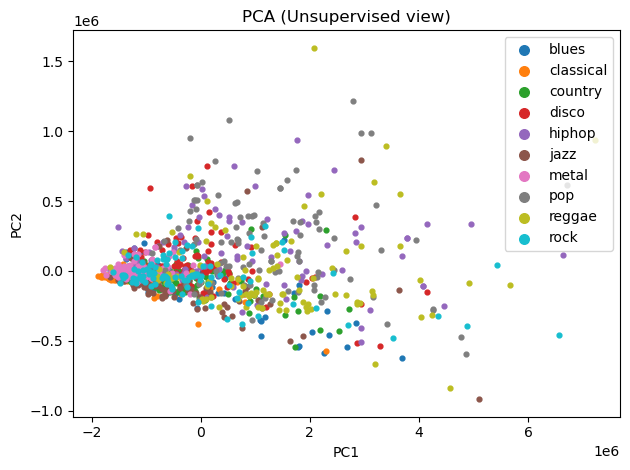

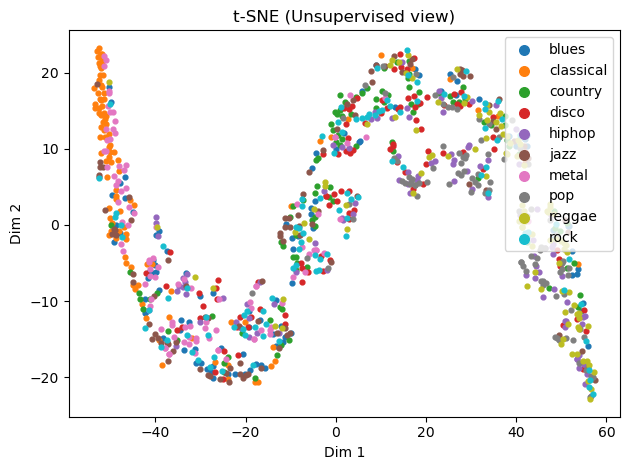

In [3]:
import numpy as np, pandas as pd, os
from sklearn.cluster import KMeans
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
from sklearn.naive_bayes import GaussianNB
from sklearn.mixture import GaussianMixture, BayesianGaussianMixture
from viz import pca_scatter, tsne_scatter

df = pd.read_csv("reports/gtzan_features.csv")
X = df.drop(columns=["label", "path"]).values
y = df["label"].values

k = len(np.unique(y))
km = KMeans(n_clusters=k, n_init=10, random_state=42)
y_km = km.fit_predict(X)
print("K-Means NMI=%.3f ARI=%.3f" % (
    normalized_mutual_info_score(y, y_km),
    adjusted_rand_score(y, y_km)
))

pca_scatter(X, y, title="PCA (Unsupervised view)")
tsne_scatter(X, y, title="t-SNE (Unsupervised view)", perplexity=30, n_iter=1000)

gnb = GaussianNB().fit(X, y)
print("GaussianNB (resubstitution) acc:", (gnb.predict(X) == y).mean())

classes = sorted(np.unique(y))
gmms = {c: GaussianMixture(n_components=2, random_state=42).fit(X[y==c]) for c in classes}
import numpy as np
log_probs = np.stack([gmms[c].score_samples(X) for c in classes], axis=1)
y_pred = np.array([classes[i] for i in np.argmax(log_probs, axis=1)])
print("GMM (uniform prior, resubstitution) acc:", (y_pred == y).mean())

bgm = BayesianGaussianMixture(n_components=10, random_state=42)
cl = bgm.fit_predict(X)
print("Bayesian GMM NMI=%.3f ARI=%.3f" % (
    normalized_mutual_info_score(y, cl),
    adjusted_rand_score(y, cl)
))
